# Notebook 04 — Multi-Asset Optimal Quotes (IG + HY)


## What this notebook is about

Notebooks 01–03 treated IG and HY **independently**. In practice, they are **correlated** ($\rho = 0.9$). A market maker holding IG inventory faces risk not only from IG price moves but also from HY price moves (via the covariance).

This notebook solves the **multi-asset ODE** (Eq. 5.13, specialised to $d = 2$) and shows that:
1. Each asset's optimal quote depends on the inventory in **both** assets (Figs 17–18).
2. The strength of this cross-asset effect is governed by $\rho$ (Fig 19).

> *"The more correlated the two assets, the more conservatively (respectively aggressively) the market maker should quote at the bid when he has a long (respectively short) inventory in the other asset."* — Paper p. 41

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, HY, GAMMA, T, RHO
from market_making.core.solver_2d import solve_2d
from market_making.core.solver_1d import solve_general


plt.style.use("seaborn-v0_8")
%matplotlib inline

## 1. Multi-asset model (Paper §5)

Each asset $i \in \{1, \ldots, d\}$ follows:

$$dS^i_t = \sigma_i \, dW^i_t$$

where $(W^1, \ldots, W^d)$ is a $d$-dimensional Brownian motion with correlation matrix $(\rho_{i,j})$. The **variance-covariance matrix** is:

$$\Sigma = (\rho_{i,j} \sigma_i \sigma_j)_{1 \leq i,j \leq d}$$

For $d = 2$ (IG, HY):

$$\Sigma = \begin{pmatrix} \sigma_{\text{IG}}^2 & \rho \, \sigma_{\text{IG}} \sigma_{\text{HY}} \\ \rho \, \sigma_{\text{IG}} \sigma_{\text{HY}} & \sigma_{\text{HY}}^2 \end{pmatrix}$$

Asset $i$ is traded $\Delta_i$ units at a time. Inventory $q^i_t = n^i_t \cdot \Delta_i$, with $n^i \in \{-Q_i, \ldots, +Q_i\}$.

Each asset has its **own** intensity: $\Lambda^i(\delta) = A_i \, e^{-k_i \delta}$. The intensities are assumed **independent across assets**, only the prices are correlated.


The same dimensionality reduction (§3) applies. The value function $\theta(t, \mathbf{n})$ satisfies:

$$\partial_t \theta + \tfrac{1}{2}\gamma \, \mathbf{q}^\top \Sigma \, \mathbf{q} - \sum_{i=1}^{d} \Big[ \mathbb{1}_{n_i < Q_i} \, H^i_\xi\!\left(\frac{\theta(\mathbf{n}) - \theta(\mathbf{n} + e_i)}{\Delta_i}\right) + \mathbb{1}_{n_i > -Q_i} \, H^i_\xi\!\left(\frac{\theta(\mathbf{n}) - \theta(\mathbf{n} - e_i)}{\Delta_i}\right) \Big] = 0$$

**Key difference vs single-asset**: the inventory penalty term $\frac{1}{2}\gamma \, \mathbf{q}^\top \Sigma \, \mathbf{q}$ **couples** the assets through $\rho$:

$$\tfrac{1}{2}\gamma \, \mathbf{q}^\top \Sigma \, \mathbf{q} = \tfrac{1}{2}\gamma \Big( \sigma_1^2 q_1^2 + 2\rho\,\sigma_1\sigma_2\,q_1 q_2 + \sigma_2^2 q_2^2 \Big)$$

The cross-term $\rho\,\sigma_1\sigma_2\,q_1 q_2$ is what makes the IG market maker care about HY inventory (and vice versa).


Same formula as single-asset, applied per asset:

$$\delta^{i,b*}(t, \mathbf{n}) = \tilde{\delta}^*_\xi\!\left(\frac{\theta(\mathbf{n}) - \theta(\mathbf{n} + e_i)}{\Delta_i}\right)$$



## 3. Parameters (Paper §6.3, p. 39)

Same per-asset parameters as before. The new ingredient is the **correlation** $\rho$ between IG and HY.


In [3]:
Q1, Q2 = int(IG["Q"]), int(HY["Q"])
N_grid = (2*Q1 + 1) * (2*Q2 + 1)

print(f"IG:  σ = {IG['sigma']:.2e},  A = {IG['A']:.2e},  k = {IG['k']:.2e},  Δ = {IG['Delta']:.2e},  Q = {Q1}")
print(f"HY:  σ = {HY['sigma']:.2e},  A = {HY['A']:.2e},  k = {HY['k']:.2e},  Δ = {HY['Delta']:.2e},  Q = {Q2}")
print(f"γ  = {GAMMA:.1e},  ρ = {RHO},  T = {T} s")
print(f"Grid: ({2*Q1+1}) × ({2*Q2+1}) = {N_grid} points")

IG:  σ = 5.83e-06,  A = 9.10e-04,  k = 1.79e+04,  Δ = 5.00e+07,  Q = 4
HY:  σ = 2.15e-05,  A = 1.06e-03,  k = 5.47e+03,  Δ = 1.00e+07,  Q = 4
γ  = 6.0e-05,  ρ = 0.9,  T = 7200 s
Grid: (9) × (9) = 81 points


In [4]:
# Covariance matrix  Σ = [[σ1², ρ·σ1·σ2], [ρ·σ1·σ2, σ2²]]
s1, s2 = IG["sigma"], HY["sigma"]
Sigma = np.array([[s1**2,         RHO * s1 * s2],
                   [RHO * s1 * s2, s2**2]])
print(f"\nΣ = \n{Sigma}")


Σ = 
[[3.398890e-11 1.128105e-10]
 [1.128105e-10 4.622500e-10]]


In [5]:
# Inventory penalty at (n1, n2) = (3, 3):  ½γ q^T Σ q
q_test = np.array([3 * IG["Delta"], 3 * HY["Delta"]])
pen = 0.5 * GAMMA * q_test @ Sigma @ q_test
pen_ig_only = 0.5 * GAMMA * s1**2 * (3 * IG["Delta"])**2
pen_hy_only = 0.5 * GAMMA * s2**2 * (3 * HY["Delta"])**2
pen_cross = GAMMA * RHO * s1 * s2 * (3 * IG["Delta"]) * (3 * HY["Delta"])

print(f"\nInventory penalty at (n1,n2)=(3,3):")
print(f"  IG-only term:    {pen_ig_only:.4e}")
print(f"  HY-only term:    {pen_hy_only:.4e}")
print(f"  Cross term (ρ):  {pen_cross:.4e}")
print(f"  Total:           {pen:.4e}")
print(f"  Cross / Total:   {pen_cross/pen:.1%}")



Inventory penalty at (n1,n2)=(3,3):
  IG-only term:    2.2943e+01
  HY-only term:    1.2481e+01
  Cross term (ρ):  3.0459e+01
  Total:           6.5882e+01
  Cross / Total:   46.2%


## 4. Solve the 2D ODE (Eq. 5.13, Model A)

**Method**: Same implicit backward Euler + Newton as 1D, but:
- State vector $\theta \in \mathbb{R}^{81}$ (was $\mathbb{R}^{9}$ in 1D).
- Jacobian is a **sparse** $81 \times 81$ matrix (vs dense $9 \times 9$).
- Newton uses `scipy.sparse.linalg.spsolve` at each iteration.


In [6]:
N_T_2D = 7200  

print(f"Solving 2D Model A at ρ = {RHO} (N_t = {N_T_2D}, dt = {T/N_T_2D:.1f} s) ...")
t0 = time.time()
sol = solve_2d(IG, HY, GAMMA, RHO, T, xi=GAMMA, N_t=N_T_2D)
elapsed = time.time() - t0

print(f"  Done in {elapsed:.1f} s  ({N_grid} grid points × {N_T_2D} time steps)")


Solving 2D Model A at ρ = 0.9 (N_t = 7200, dt = 1.0 s) ...
  2D solver: step 720/7200  (Newton iters=12, |corr|=3.23e-12)
  2D solver: step 1440/7200  (Newton iters=12, |corr|=1.92e-12)
  2D solver: step 2160/7200  (Newton iters=12, |corr|=2.97e-12)
  2D solver: step 2880/7200  (Newton iters=12, |corr|=3.33e-12)
  2D solver: step 3600/7200  (Newton iters=12, |corr|=2.46e-12)
  2D solver: step 4320/7200  (Newton iters=12, |corr|=1.56e-12)
  2D solver: step 5040/7200  (Newton iters=12, |corr|=2.37e-12)
  2D solver: step 5760/7200  (Newton iters=12, |corr|=2.89e-12)
  2D solver: step 6480/7200  (Newton iters=12, |corr|=2.70e-12)
  2D solver: step 7200/7200  (Newton iters=12, |corr|=3.14e-12)
  Done in 101.7 s  (81 grid points × 7200 time steps)


## 5. Figure 17 — IG bid surface: $\delta^{\text{IG},b}(0, n_{\text{IG}}, n_{\text{HY}})$

**Paper reference** (p. 40):
> *"In Figures 17 and 18, we have plotted the optimal bid quotes for the two indices. We see that the market maker's inventory on both indices influences his quotes. Because the correlation coefficient is positive, $(q_{\text{IG}}, q_{\text{HY}}) \mapsto \delta^{\text{IG},b}$ and $(q_{\text{IG}}, q_{\text{HY}}) \mapsto \delta^{\text{HY},b}$ are increasing in $q_{\text{IG}}$ and $q_{\text{HY}}$."*

The surface should be:
- **Increasing in $n_{\text{IG}}$** (same-asset effect, as in 1D).
- **Increasing in $n_{\text{HY}}$** (cross-asset effect, due to $\rho > 0$).

The bid is defined for $n_i < Q_i$ (the market maker can still buy one more lot).


In [7]:
def surface_plot(sol, asset_label, quote_key, fig_num):
    """3D surface plot of bid quotes over the 2D inventory grid.

    Parameters
    ----------
    sol          : dict from solve_2d
    asset_label  : "IG" or "HY"
    quote_key    : "delta_bid_1" or "delta_bid_2"
    fig_num      : paper figure number (17 or 18)
    """
    n1_range = np.arange(-Q1, Q1)       # bid defined for n1 < Q1
    n2_range = np.arange(-Q2, Q2 + 1)
    N1, N2 = np.meshgrid(n1_range, n2_range, indexing="ij")
    Z = np.full_like(N1, np.nan, dtype=float)

    for i, n1 in enumerate(n1_range):
        for j, n2 in enumerate(n2_range):
            key = (n1, n2)
            if key in sol["idx"]:
                jj = sol["idx"][key]
                Z[i, j] = sol[quote_key][0, jj]

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(N1, N2, Z, cmap="viridis", alpha=0.8,
                    edgecolor="k", linewidth=0.3)
    ax.set_xlabel("n_IG (lots)")
    ax.set_ylabel("n_HY (lots)")
    ax.set_zlabel(f"$\\delta^{{{asset_label},bid}}$")
    ax.set_title(f"Fig {fig_num}: $\\delta^{{{asset_label},bid}}(0, n_{{IG}}, n_{{HY}})$"
                 f"  —  $\\rho$ = {RHO}")
    fig.tight_layout()
    plt.show()


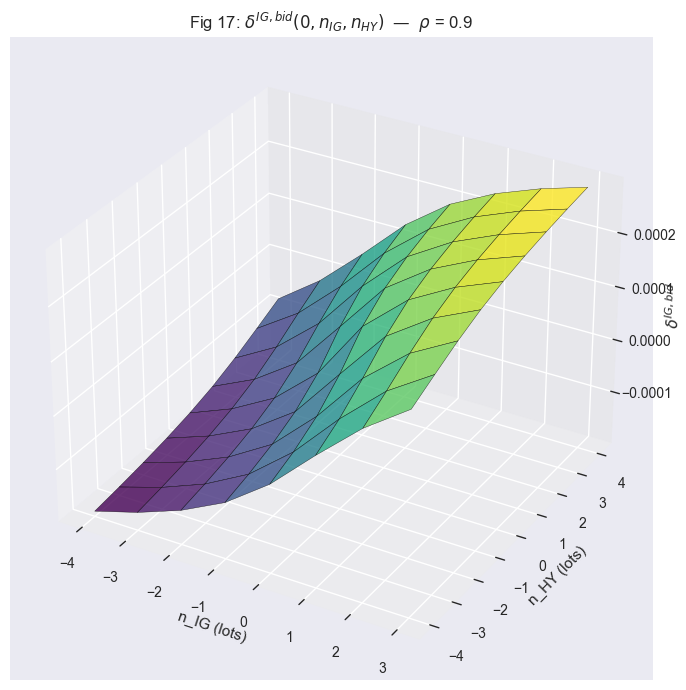

In [8]:
surface_plot(sol, "IG", "delta_bid_1", 17)

## 6. Figure 18 — HY bid surface: $\delta^{\text{HY},b}(0, n_{\text{IG}}, n_{\text{HY}})$

Same structure as Fig 17 but for the HY asset. The cross-asset effect should also be visible: the HY bid increases when the IG inventory grows (because $\rho > 0$ means IG gains correlate with HY gains, so holding IG inventory is effectively holding some HY risk too).


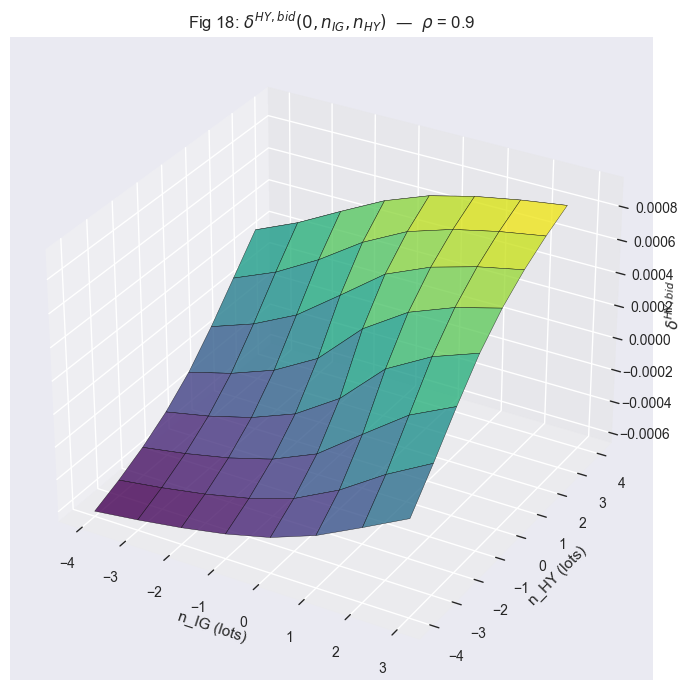

In [9]:
surface_plot(sol, "HY", "delta_bid_2", 18)


## 7. Figure 19 — Cross-asset effect for varying $\rho$

**Paper reference** (p. 41):
> *"Figure 19 represents, for these different values of $\rho$, the bid quote $\delta^{\text{HY},b}(0, q_{\text{IG}}, 0)$ for the HY index, when the inventory with respect to the HY index is equal to 0, for different values of the inventory with respect to the IG index."*

> *"We see that the correlation coefficient has a strong influence on the optimal quote: the more correlated the two assets, the more conservatively (respectively aggressively) the market maker should quote at the bid when he has a long (respectively short) inventory in the other asset."*

This is the key figure of §6.3. We fix $n_{\text{HY}} = 0$ and plot $n_{\text{IG}} \mapsto \delta^{\text{HY},b}$ for $\rho \in \{0, 0.3, 0.6, 0.9\}$.

At $\rho = 0$: the HY bid should be **flat** (IG inventory doesn't matter).  
At $\rho = 0.9$: the HY bid should tilt **strongly** with IG inventory.


<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_21573/3863698691.py:27: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel("$\delta^{HY,bid}(0, n_{IG}, n_{HY}=0)$")


  Solving 2D at ρ = 0.0 ...
  2D solver: step 720/7200  (Newton iters=12, |corr|=1.71e-12)
  2D solver: step 1440/7200  (Newton iters=12, |corr|=2.53e-12)
  2D solver: step 2160/7200  (Newton iters=12, |corr|=1.79e-12)
  2D solver: step 2880/7200  (Newton iters=12, |corr|=1.57e-12)
  2D solver: step 3600/7200  (Newton iters=12, |corr|=1.60e-12)
  2D solver: step 4320/7200  (Newton iters=12, |corr|=3.52e-12)
  2D solver: step 5040/7200  (Newton iters=12, |corr|=1.68e-12)
  2D solver: step 5760/7200  (Newton iters=12, |corr|=1.38e-12)
  2D solver: step 6480/7200  (Newton iters=12, |corr|=3.23e-12)
  2D solver: step 7200/7200  (Newton iters=12, |corr|=3.63e-12)
    Done in 104.3 s
  Solving 2D at ρ = 0.3 ...
  2D solver: step 720/7200  (Newton iters=12, |corr|=3.19e-12)
  2D solver: step 1440/7200  (Newton iters=12, |corr|=3.06e-12)
  2D solver: step 2160/7200  (Newton iters=12, |corr|=2.26e-12)
  2D solver: step 2880/7200  (Newton iters=12, |corr|=3.58e-12)
  2D solver: step 3600/7200  (

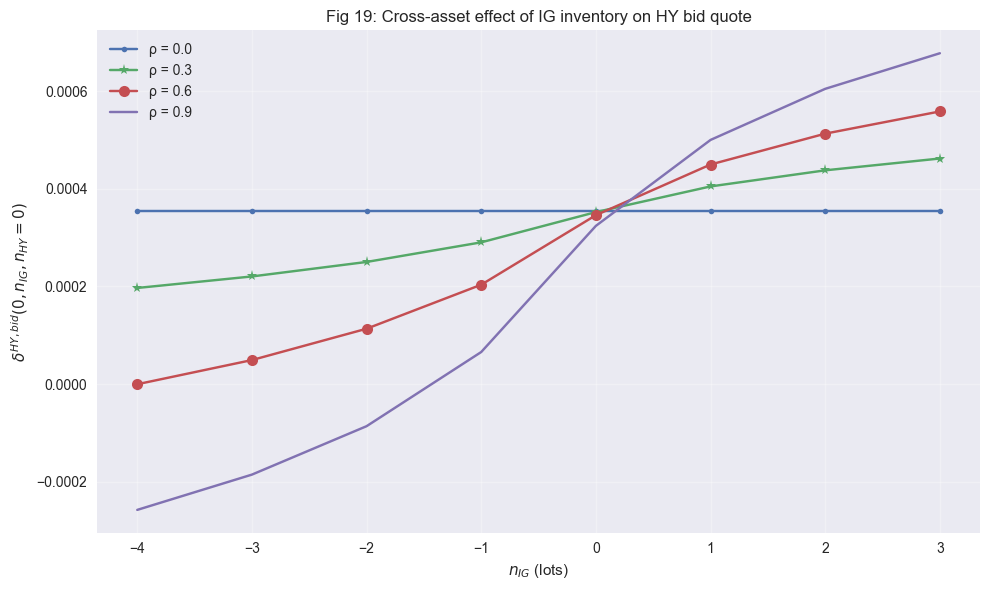

In [10]:
rho_values = [0.0, 0.3, 0.6, 0.9]
fig, ax = plt.subplots(figsize=(10, 6))

# Paper markers: ρ=0.9 (crosses), ρ=0.6 (circles), ρ=0.3 (stars), ρ=0 (dots)
markers = {0.9: "x", 0.6: "o", 0.3: "*", 0.0: "."}

for rho_val in rho_values:
    print(f"  Solving 2D at ρ = {rho_val} ...")
    t0 = time.time()
    sol_rho = solve_2d(IG, HY, GAMMA, rho_val, T, xi=GAMMA, N_t=N_T_2D)
    print(f"    Done in {time.time()-t0:.1f} s")

    n1_range = np.arange(-Q1, Q1)  # bid defined for n1 < Q1
    db_hy = []
    for n1 in n1_range:
        key = (n1, 0)
        if key in sol_rho["idx"]:
            jj = sol_rho["idx"][key]
            db_hy.append(sol_rho["delta_bid_2"][0, jj])
        else:
            db_hy.append(np.nan)

    m = markers.get(rho_val, "s")
    ax.plot(n1_range, db_hy, f"{m}-", ms=8, label=f"ρ = {rho_val}")

ax.set_xlabel("$n_{IG}$ (lots)")
ax.set_ylabel("$\delta^{HY,bid}(0, n_{IG}, n_{HY}=0)$")
ax.set_title("Fig 19: Cross-asset effect of IG inventory on HY bid quote")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## A.2 Numerical summary — key quote values at $\rho = 0.9$

Values at specific inventory points for cross-checking.


In [11]:
print(f"{'(n_IG, n_HY)':<18s}  {'δ^IG_bid':>12s}  {'δ^IG_ask':>12s}  {'δ^HY_bid':>12s}  {'δ^HY_ask':>12s}")
print("─" * 72)

test_points = [(0,0), (3,0), (0,3), (3,3), (-3,0), (-3,-3)]
for (n1, n2) in test_points:
    if (n1, n2) in sol["idx"]:
        j = sol["idx"][(n1, n2)]
        db1 = sol["delta_bid_1"][0, j]
        da1 = sol["delta_ask_1"][0, j]
        db2 = sol["delta_bid_2"][0, j]
        da2 = sol["delta_ask_2"][0, j]
        def fmt(v):
            return f"{v:>12.6e}" if np.isfinite(v) else f"{'NaN':>12s}"
        print(f"({n1:+d}, {n2:+d}){'':<10s}  {fmt(db1)}  {fmt(da1)}  {fmt(db2)}  {fmt(da2)}")


(n_IG, n_HY)            δ^IG_bid      δ^IG_ask      δ^HY_bid      δ^HY_ask
────────────────────────────────────────────────────────────────────────
(+0, +0)            1.072904e-04  1.072904e-04  3.241349e-04  3.241349e-04
(+3, +0)            2.581080e-04  -1.217468e-04  6.774772e-04  -1.850592e-04
(+0, +3)            1.827884e-04  -1.228266e-05  7.873071e-04  -3.341206e-04
(+3, +3)            2.857321e-04  -1.569006e-04  9.425116e-04  -5.255888e-04
(-3, +0)            -1.217468e-04  2.581080e-04  -1.850592e-04  6.774772e-04
(-3, -3)            -1.569006e-04  2.857321e-04  -5.255888e-04  9.425116e-04


## A.3 Comparison: 2D solution vs independent 1D solutions

If $\rho = 0$, the 2D solution should reduce to two independent 1D problems. Even at $\rho = 0.9$, we can measure how much the cross-asset coupling changes the quotes.

We compare $\delta^{\text{IG},b}(0, n_\text{IG}, n_\text{HY}=0)$ from the 2D solver against $\delta^{\text{IG},b}(0, n_\text{IG})$ from the 1D solver.


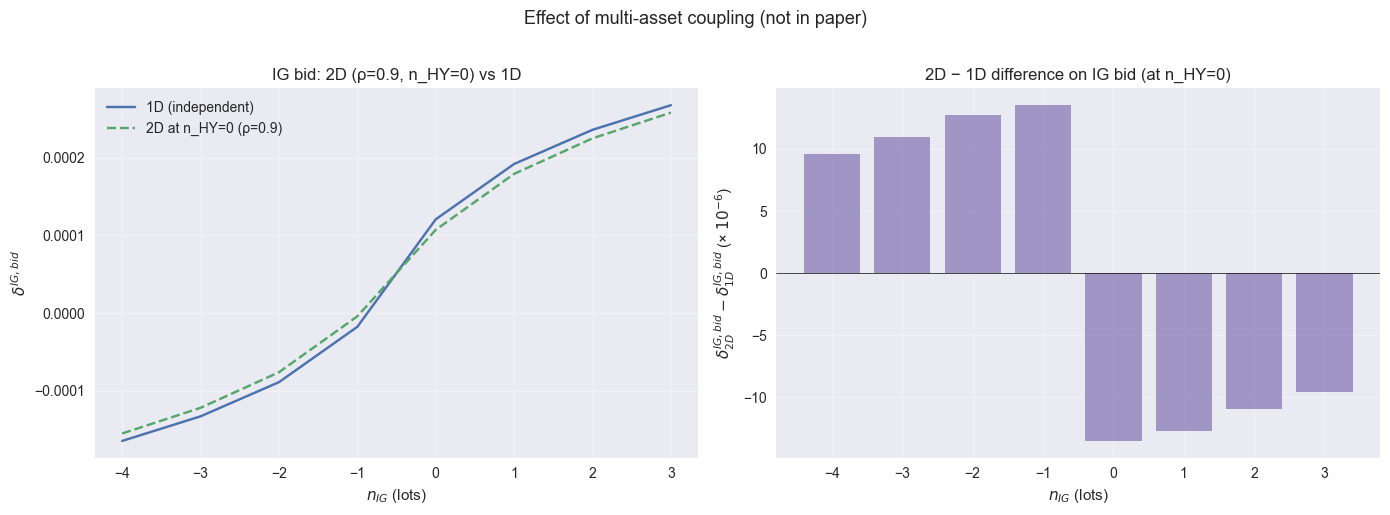

Max |2D − 1D| / |1D|: 77.22%
Even at n_HY=0, ρ-coupling changes the IG quotes because the ODE's θ
is solved on the full 2D grid and the inventory penalty structure differs.


In [12]:
# Solve 1D for IG
sol_1d_ig = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T_2D)

# Extract 2D quotes along n_HY=0 cross-section
n1_range = np.arange(-Q1, Q1)
db_2d_IG = []
for n1 in n1_range:
    key = (n1, 0)
    if key in sol["idx"]:
        jj = sol["idx"][key]
        db_2d_IG.append(sol["delta_bid_1"][0, jj])
    else:
        db_2d_IG.append(np.nan)
db_2d_IG = np.array(db_2d_IG)

# Extract 1D quotes for the same n range
db_1d_IG = []
for n1 in n1_range:
    idx_1d = int(n1 + Q1)
    db_1d_IG.append(sol_1d_ig["delta_bid"][0, idx_1d])
db_1d_IG = np.array(db_1d_IG)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay
ax1.plot(n1_range, db_1d_IG, "x-", ms=8, label="1D (independent)")
ax1.plot(n1_range, db_2d_IG, "o--", ms=6, mfc="none", label=f"2D at n_HY=0 (ρ={RHO})")
ax1.set_xlabel("$n_{IG}$ (lots)")
ax1.set_ylabel("$\\delta^{IG,bid}$")
ax1.set_title("IG bid: 2D (ρ=0.9, n_HY=0) vs 1D")
ax1.legend()
ax1.grid(alpha=0.3)

# Right: difference
mask = np.isfinite(db_2d_IG) & np.isfinite(db_1d_IG)
diff = db_2d_IG[mask] - db_1d_IG[mask]
ax2.bar(n1_range[mask], diff * 1e6, color="C3", alpha=0.7)
ax2.set_xlabel("$n_{IG}$ (lots)")
ax2.set_ylabel("$\\delta^{IG,bid}_{2D} - \\delta^{IG,bid}_{1D}$ (× $10^{-6}$)")
ax2.set_title("2D − 1D difference on IG bid (at n_HY=0)")
ax2.axhline(0, color="k", lw=0.5)
ax2.grid(alpha=0.3)

fig.suptitle("Effect of multi-asset coupling (not in paper)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

rel_diff = np.abs(diff) / np.abs(db_1d_IG[mask])
print(f"Max |2D − 1D| / |1D|: {rel_diff.max():.2%}")
print(f"Even at n_HY=0, ρ-coupling changes the IG quotes because the ODE's θ")
print(f"is solved on the full 2D grid and the inventory penalty structure differs.")


## A.4 Heatmap view of bid quotes

An alternative to the 3D surface — easier to read exact values and see the gradient directions.


IG bid heatmap NaNs: 0
HY bid heatmap NaNs: 8


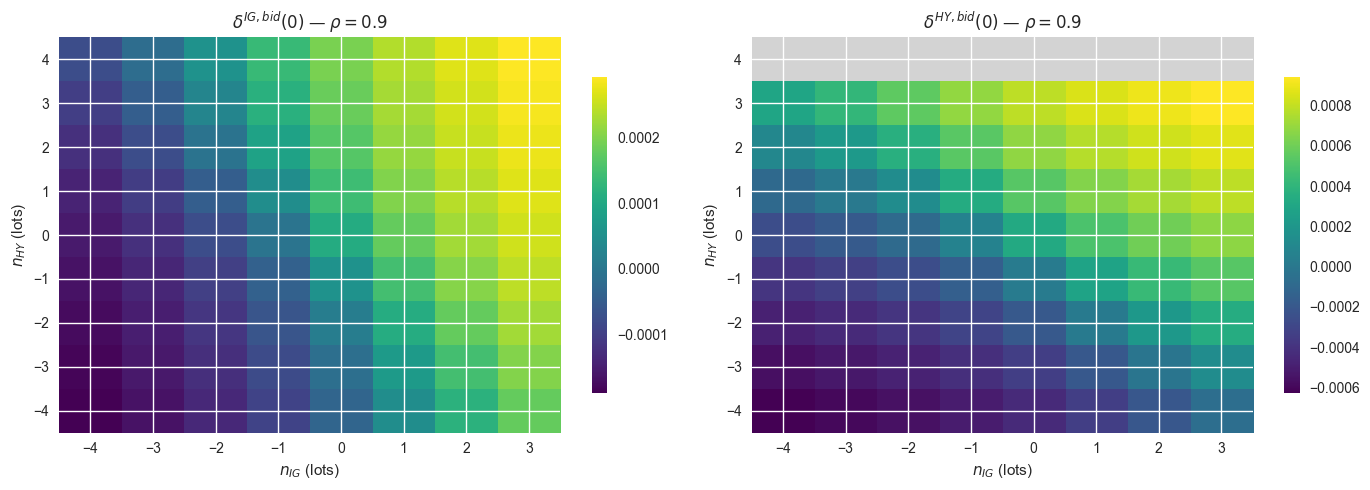

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, quote_key, asset in [(axes[0], "delta_bid_1", "IG"), (axes[1], "delta_bid_2", "HY")]:
    n1_range = np.arange(-Q1, Q1)      # bid defined only for n_IG < Q1
    n2_range = np.arange(-Q2, Q2 + 1)
    

    Z = np.full((len(n2_range), len(n1_range)), np.nan)

    for ix, n1 in enumerate(n1_range):
        for iy, n2 in enumerate(n2_range):
            j = sol["idx"][(n1, n2)]
            Z[iy, ix] = sol[quote_key][0, j]

    print(f"{asset} bid heatmap NaNs:", np.isnan(Z).sum())

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgray")

    im = ax.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=[n1_range[0]-0.5, n1_range[-1]+0.5, n2_range[0]-0.5, n2_range[-1]+0.5],
        cmap=cmap,
        interpolation="nearest"
    )
    ax.set_xlabel("$n_{IG}$ (lots)")
    ax.set_ylabel("$n_{HY}$ (lots)")
    ax.set_title(f"$\\delta^{{{asset},bid}}(0)$ — $\\rho={RHO}$")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


For a bid quote on asset \(i\), the quote is defined only if the market maker can still **buy one additional lot**, i.e.

\[
n_i < Q_i
\]

For the HY asset:

- \(Q_{HY} = 4\)
- The grid was defined as `n2_range = np.arange(-Q2, Q2 + 1)`, which gives the values \(-4, \ldots, 4\).

However, the HY bid is **not defined when \(n_{HY} = +4\)**, because the market maker is already at the **maximum inventory limit** and cannot buy another lot.

Therefore, every state of the form

\[
(n_{IG}, n_{HY}=4)
\]

is **inadmissible for the HY bid quote**.

Since `n1_range = np.arange(-Q1, Q1)` contains **8 values** (\(-4, \ldots, 3\)), this results in exactly **8 NaN values** in the heatmap.

These NaNs correspond to the entire **\(n_{HY}=4\) boundary row**, and therefore reflect the **inventory constraint of the model**, not a numerical issue.

## A.5 Value function $\theta(0, n_\text{IG}, n_\text{HY})$

The value function encodes the full strategy. It should be:
- Symmetric: $\theta(n_1, n_2) = \theta(-n_1, -n_2)$.
- Concave in both directions (inventory is costly).
- Maximum at $(0, 0)$.


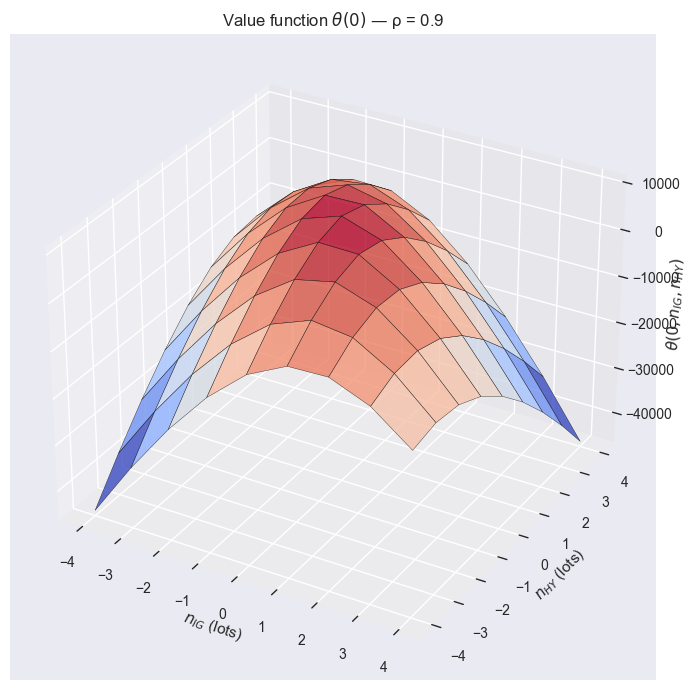

θ(0, 0, 0) = 1.043366e+04  (should be the maximum)


In [14]:
n1_range = np.arange(-Q1, Q1 + 1)
n2_range = np.arange(-Q2, Q2 + 1)
N1, N2 = np.meshgrid(n1_range, n2_range, indexing="ij")
Z = np.full_like(N1, np.nan, dtype=float)

for i, n1 in enumerate(n1_range):
    for j, n2 in enumerate(n2_range):
        key = (n1, n2)
        if key in sol["idx"]:
            jj = sol["idx"][key]
            Z[i, j] = sol["theta"][0, jj]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(N1, N2, Z, cmap="coolwarm", alpha=0.8, edgecolor="k", linewidth=0.3)
ax.set_xlabel("$n_{IG}$ (lots)")
ax.set_ylabel("$n_{HY}$ (lots)")
ax.set_zlabel("$\\theta(0, n_{IG}, n_{HY})$")
ax.set_title(f"Value function $\\theta(0)$ — ρ = {RHO}")
fig.tight_layout()
plt.show()

# Report max
j_00 = sol["idx"][(0, 0)]
print(f"θ(0, 0, 0) = {sol['theta'][0, j_00]:.6e}  (should be the maximum)")


The value function is maximal near (0,0), as expected.
Moving away from zero inventory lowers theta because inventory risk enters through
the quadratic penalty 1/2 * gamma * q^T Sigma q.
The surface is roughly symmetric under simultaneous sign reversal.